# Modern Methods of Data Analysis — Homework 2 (Part 2)

In [ ]:
import collections

import numpy
import sklearn.cluster
import scipy.sparse.linalg
import matplotlib.pyplot as plt

RANDOM_STATE = 0

In [2]:
! wget -O "./yahoo.zip" "https://www.dropbox.com/s/ii1e09dx6o2ktit/yahoo.zip?dl=1"
! unzip -o "./yahoo.zip" -d "./yahoo"

--2026-05-31 19:41:43--  https://www.dropbox.com/s/ii1e09dx6o2ktit/yahoo.zip?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 2620:100:6026:18::a27d:4612, 162.125.70.18
Connecting to www.dropbox.com (www.dropbox.com)|2620:100:6026:18::a27d:4612|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/l522l053ajtvx7lerzzy8/yahoo.zip?rlkey=z0av7w618fboe50jtjuqkby9r&dl=1 [following]
--2026-05-31 19:41:44--  https://www.dropbox.com/scl/fi/l522l053ajtvx7lerzzy8/yahoo.zip?rlkey=z0av7w618fboe50jtjuqkby9r&dl=1
Reusing existing connection to [www.dropbox.com]:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucefa470d64c78013e6cbcecc235.dl.dropboxusercontent.com/cd/0/inline/DBgZcpWNLBCWyhDqW0M3tLnmICnhI65DSUtC3wpEUReqng3lDibQHkRhTf_81OSZUnx_CvWkOYXUHw86PhwpURraNZaRGDlEhhcUEXBU8PqolWABn9wEml9o7QkaqAFQIN8/file?dl=1# [following]
--2026-05-31 19:41:44--  https://ucefa470d64c78013e6cbcecc235.dl.dropboxusercontent.com/cd/0

3000 2000
['12a1970 lexmark' '2 stacker' '21 black jack']


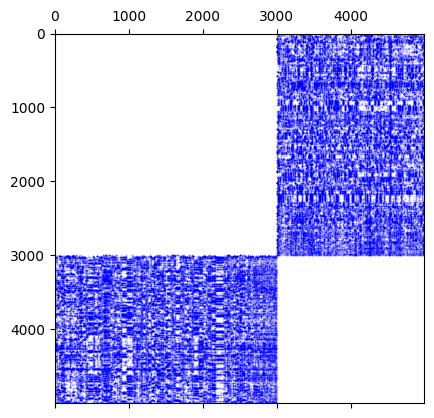

In [ ]:
# Read the edges
A = numpy.genfromtxt('yahoo/us.3k.2k.smat', dtype=int)
N, M, n_connections, A = *A[0], A[1:, :2]
print(N, M)

# Read the labels
with open("yahoo/us.3k.2k.trms", 'r') as iofile:
    labels = numpy.array([ l[:-1] for l in iofile.readlines() ])
print(labels[:3])

A_small = numpy.zeros((N, M))
A_small[A[:, 0], A[:, 1]] = 1
assert sum(sum(A_small)) == 92345

# Combine everything into an adjacency matrix
A = numpy.vstack([
    numpy.hstack([numpy.zeros((N, N)), A_small]),
    numpy.hstack([A_small.T, numpy.zeros((M, M))])
])
plt.spy(A, markersize=0.05, color='blue')

[-0.      0.6031  1.2188  1.4114  1.4809  1.8318]


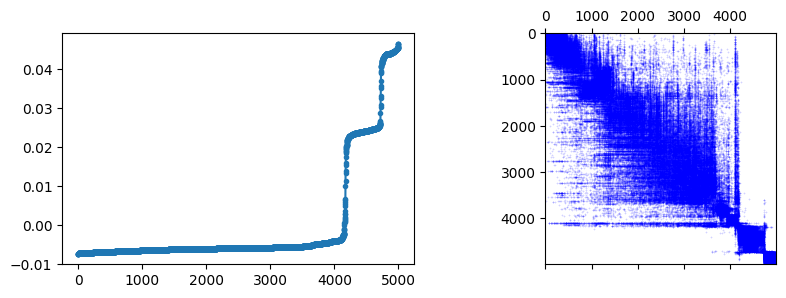

In [ ]:
D = numpy.diag(A.sum(axis=1))
L = D - A # Laplacian

eigvals, eigvecs = scipy.sparse.linalg.eigsh(L, which='SA', rng=RANDOM_STATE)
print(eigvals.round(4))
scores = -eigvecs[:, 1]
label_scores = scores[:N]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(numpy.sort(scores), '.-')
ax2.spy(
    A[numpy.argsort(scores), :][:, numpy.argsort(scores)],
    markersize=0.05,
    color='blue'
)

As in the tutorial provided with the task, we get one zero eigenvalue, which corresponds to the single connected component in the graph. The next eigenvalue is 0.603, which contains the information required for clustering according to the spectral algorithm.

Looking at the corresponding eigenvector, one observes two clear "jumps", which relate to the cluster cuts we are aiming for. To find the clusters themselves, one should run KMeans (or any other algorithm) on those eigenvector values. For simplicity, we will just partition the values manually based on the picture.

In [5]:
print(f"Cluster 1: ", labels[label_scores < 0.00][:10])
print(f"Cluster 2: ", labels[(label_scores > 0.02) & (label_scores < 0.03)][:10])
print(f"Cluster 3: ", labels[label_scores > 0.04][:10])

Cluster 1:  ['12a1970 lexmark' '2 stacker' '2nd mortgage' 'acapulco hotel'
 'accept account card credit merchant' 'accept card credit'
 'accept card credit online' 'accessory computer' 'accessory desk'
 'accommodation']
Cluster 2:  ['21 black jack' 'baccarat' 'baccarat casino game' 'baccarat online'
 'baccarat play' 'baseball bet' 'baseball betting' 'baseball betting line'
 'baseball gambling' 'baseball odds']
Cluster 3:  ['adult amateur video' 'adult entertainment' 'adult film' 'adult movie'
 'adult movie sex' 'adult movie xxx' 'adult picture' 'adult porn'
 'adult sex' 'adult sex video']


Cluster 1 contains the overwhelming majority of terms, so one probably needs to split it further for a good, precise interpretation. For now, we will leave it just as a set of generic terms. Cluster 2 collects the gambling/betting terms, which is exactly what David Gleich found in the tutorial. Finally, cluster 3 is also easily generalizable as the collection of adult, 18+ content.

For a more precise look into cluster 1, let's utilize a ready-to-use implementation of spectral clustering from scikit-learn.

In [6]:
sc = sklearn.cluster.SpectralClustering(
    n_clusters=10, affinity='precomputed', random_state=RANDOM_STATE
)
clusters = sc.fit_predict(A)[:N]

print("Clusters:", collections.Counter(clusters))
for c in sorted(set(clusters)):
    print(f"Cluster {c}: {','.join(labels[clusters == c][:25])}")

Clusters: Counter({0: 756, 2: 579, 6: 382, 5: 346, 3: 233, 9: 205, 1: 194, 7: 171, 4: 90, 8: 44})
Cluster 0: accept account card credit merchant,accept card credit,accept card credit online,account card credit merchant,account cost low merchant,account ecommerce merchant,account internet merchant,account merchant,account merchant online,account merchant provider,account merchant service,ad banner,add url,address internet,address web,advertise,advertise site web,advertising,advertising banner,advertising business,advertising campaign,advertising click pay per,advertising email,advertising engine search,advertising free
Cluster 1: adult,adult amateur video,adult entertainment,adult film,adult movie,adult movie sex,adult movie xxx,adult picture,adult porn,adult sex,adult sex video,adult site,adult site web,adult video,adult video xxx,adult xxx,amateur blow job,amateur erotica,amateur hardcore,amateur naked,amateur nude,amateur nude photo,amateur nude woman,amateur pic sex,amateur picture 

- Cluster 0 is about credits, merchants, and advertisement;
- Cluster 1 collects the terms for adult content, which we have already seen previously;
- Cluster 2 is about accommodation, travel, hotels;
- Cluster 3 shows terms like mortgage, card credit, and visas;
- Cluster 4 is about personal ads (unlike cluster 0, which focused on business ads);
- Cluster 5 looks looks like medication;
- Cluster 6 is the one about gambling, which we have also seen before;
- Cluster 7 gathers IT terms like computer accessories, printers;
- Cluster 8 can be generalized by the word "distance" (although it is not obvious what this means; probably something about strategic planning in business);
- Cluster 9 accumulates gifts and presents.